# Analyzing Netflix Encryption: Locating Chunk Requests in TLS Traffic

**Group:** Ernie, Angelina, Yosan

**AI-Use** Claude Code

**The question.** Can a classifier trained on lightweight, per-window downlink-only traffic features
find chunk requests in an encrypted Netflix session more accurately than a simple idle-gap
heuristic? And does the bitrate estimate we build on top of those predictions actually hold up?

**How the notebook is laid out**
1. Parse the pcap and keep only Netflix video flows (Open Connect ranges, resolved hostnames, SNI)
2. Label chunk requests from the uplink, using the roughly 690-byte client-to-server TLS
   application-data records
3. Work out what the evaluation can realistically achieve before we start scoring against it
   (§3.3 and §5.1)
4. Build 250 ms window features from the downlink only
5. Set up the idle-gap heuristic as a baseline
6. Train L1 logistic regression, a random forest and gradient-boosted trees, each choosing its own
   decision threshold on an inner blocked split of the training folds
7. Evaluate with blocked, time-ordered 5-fold CV, using tolerant P/R/F1 (±1 window) and confusion
   matrices
8. Recover bitrate, reporting MAE, median AE and signed bias in kbps alongside resolution-tier
   agreement against a calibrated ladder, checked against per-connection ground truth (§9.1)
9. Results and discussion in §10. The Bronzino et al. stretch validation could not be run, and §11
   explains why

**What we found.** Gradient-boosted trees reach a pooled F1 of **0.602** against the baseline's
**0.369**, which is about 68% of the **0.884** an oracle can manage under this evaluation. Bitrate
and resolution tier are another story. Every method overestimates bitrate, GBT by 975 kbps on a
signal of roughly 2226 kbps, and a predictor that always answers "1080p" beats everything we trained
on tier agreement. §10.3 and §10.4 go into both.

## 0. Setup

In [1]:
import ipaddress
import socket
import struct
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scapy.utils import RawPcapReader

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

pd.set_option("display.max_columns", 50)

DATA_DIR = Path(".")
PCAP_PATH = DATA_DIR / "netflix.pcap"
CSV_PATH = DATA_DIR / "netflix.csv.gz"

CLIENT_IP = "192.168.43.72"
WINDOW_S = 0.25          # feature window
CHUNK_DURATION_S = 4.0   # Netflix media chunk length (approx.)
N_FOLDS = 5
TOL_WINDOWS = 1          # ±1 window tolerance for request detection

## 1. Load the capture

**What the data is.** A single live Netflix viewing session, captured on 11 February 2018 in Paris
and carried over from the hands-on project. One client at `192.168.43.72` produces 141,471 packets
across 495.8 seconds. It is a passive packet capture and nothing in it is labelled, so every label
we use later has to be derived rather than looked up, which is what §3 does and what makes the
circularity discussion in §10.2 necessary.

The first minute or so also isn't Netflix at all. The capture opens with DNS, Google, YouTube,
DoubleClick and Akamai traffic, and Netflix's own API and UI servers appear alongside the video
throughout, so §2 filters all of that out before anything else happens.

**The two files.** We have two files covering the same 141,471 packets, and they each hold something
the other is missing.

`netflix.csv.gz` is a Wireshark GUI export with columns `No., Time, Source, Destination, Protocol,
Length, Info`, and it comes with resolved hostnames. What it doesn't give us is ports, TCP payload
length or SNI.

`netflix.pcap` has the raw frames, but they were truncated at 200 bytes when the capture was taken.
The IP and TCP headers survive along with the first few TLS bytes, and the IP header still reports
the true packet length even though the rest of the frame is gone.

So we parse the pcap for ports, TCP sequence numbers, payload length and the TLS record type at the
start of each segment, then join the CSV's resolved hostnames back on by row order. Between them the
two files give us everything the labeling rule in §3 needs.

In [2]:
def parse_sni(p):
    # SNI from a TLS ClientHello at the start of payload p (None if absent or truncated)
    try:
        if len(p) < 6 or p[0] != 22 or p[5] != 1:
            return None
        i = 5 + 4 + 2 + 32
        i += 1 + p[i]                                         # session id
        i += 2 + struct.unpack(">H", p[i:i + 2])[0]           # cipher suites
        i += 1 + p[i]                                         # compression
        end = i + 2 + struct.unpack(">H", p[i:i + 2])[0]
        i += 2
        while i + 4 <= min(end, len(p)):
            ext_type, ext_len = struct.unpack(">HH", p[i:i + 4])
            if ext_type == 0:
                name_len = struct.unpack(">H", p[i + 7:i + 9])[0]
                name = p[i + 9:i + 9 + name_len]
                return name.decode(errors="replace") if len(name) == name_len else None
            i += 4 + ext_len
    except (IndexError, struct.error):
        return None
    return None


def read_pcap(path):
    rows, t0 = [], None
    for data, meta in RawPcapReader(str(path)):
        ts = meta.sec + meta.usec / 1e6
        t0 = ts if t0 is None else t0
        src = dst = proto = sni = None
        sport = dport = seq = tls_type = -1
        payload_len = 0
        ethertype, off = struct.unpack(">H", data[12:14])[0], 14
        if ethertype == 0x8100:                                # VLAN tag
            ethertype, off = struct.unpack(">H", data[16:18])[0], 18
        if ethertype == 0x0800 and len(data) >= off + 20:      # IPv4 only
            ihl = (data[off] & 0x0F) * 4
            ip_len = struct.unpack(">H", data[off + 2:off + 4])[0]
            proto = data[off + 9]
            src = socket.inet_ntoa(data[off + 12:off + 16])
            dst = socket.inet_ntoa(data[off + 16:off + 20])
            l4 = off + ihl
            if proto == 6 and len(data) >= l4 + 20:
                sport, dport, seq = struct.unpack(">HHI", data[l4:l4 + 8])
                doff = (data[l4 + 12] >> 4) * 4
                payload_len = ip_len - ihl - doff
                p = data[l4 + doff:]
                # Segment starts with a TLS record header: type 20-23, version major 3
                if payload_len >= 5 and len(p) >= 5 and p[0] in (20, 21, 22, 23) and p[1] == 3:
                    tls_type = p[0]
                    sni = parse_sni(p)
            elif proto == 17 and len(data) >= l4 + 8:
                sport, dport = struct.unpack(">HH", data[l4:l4 + 4])
                payload_len = ip_len - ihl - 8
        rows.append((ts - t0, src, dst, proto, sport, dport, meta.wirelen, payload_len, seq, tls_type, sni))
    return pd.DataFrame(rows, columns=["time", "src", "dst", "proto", "sport", "dport",
                                       "length", "payload_len", "seq", "tls_type", "sni"])


raw = read_pcap(PCAP_PATH)
csv = pd.read_csv(CSV_PATH, low_memory=False)
assert len(raw) == len(csv) and (raw["length"].values == csv["Length"].values).all(), "pcap/csv misaligned"

raw["uplink"] = raw["src"] == CLIENT_IP
raw["server"] = np.where(raw["uplink"], raw["dst"], raw["src"])
raw["server_host"] = np.where(raw["uplink"], csv["Destination"], csv["Source"])
raw["client_port"] = np.where(raw["uplink"], raw["sport"], raw["dport"])

print(f"{len(raw):,} packets over {raw.time.max():.1f} s")
raw.head()

141,471 packets over 495.8 s


,time,src,dst,proto,sport,dport,length,payload_len,seq,tls_type,sni,uplink,server,server_host,client_port
0,0.000000,192.168.43.72,128.93.77.234,17.0,55697,53,77,35,-1,-1,None,True,128.93.77.234,ns-vip-pro.paris.inria.fr,55697
1,0.000150,192.168.43.72,128.93.77.234,17.0,59884,53,77,35,-1,-1,None,True,128.93.77.234,ns-vip-pro.paris.inria.fr,59884
2,0.004726,192.168.43.72,128.93.77.234,17.0,61223,53,87,45,-1,-1,None,True,128.93.77.234,ns-vip-pro.paris.inria.fr,61223
3,0.006522,192.168.43.72,128.93.77.234,17.0,58785,53,87,45,-1,-1,None,True,128.93.77.234,ns-vip-pro.paris.inria.fr,58785
4,0.011103,192.168.43.72,128.93.77.234,17.0,51938,53,78,36,-1,-1,None,True,128.93.77.234,ns-vip-pro.paris.inria.fr,51938


## 2. Keep only Netflix video traffic

The capture holds a lot that isn't video. There's Google, YouTube, DoubleClick and Akamai traffic,
plus Netflix's own AWS-hosted API and UI servers (`www.netflix.com`, `*.nflxext.com` and friends).
Chunk requests only ever go to Open Connect Appliances, so we count a server as video when either
its IP falls inside a Netflix Open Connect prefix (AS2906) and it isn't obviously serving non-video
assets, or its resolved hostname or SNI is `*.nflxvideo.net`.

That second half of the first condition matters more than it looks. Sitting in an OCA prefix is
necessary but it isn't sufficient. This capture contains a server inside `198.38.96.0/19` whose SNI
is `occ-0-56-55.1.nflxso.net`, and that's Netflix's artwork and UI asset domain rather than media.
Going on IP prefix alone would quietly push its traffic into the downlink features as though it were
video. We're only talking about 0.12 MB here, but it's a systematic error rather than a rounding
one, so we exclude it on purpose rather than hoping it washes out.

The AWS-hosted API servers get dropped for the same reason. They're part of the session, but they
carry no media chunks.

In [3]:
NETFLIX_ANY_PATTERN = r"nflxvideo\.net|netflix\.com|nflxso\.net|nflxext\.com|nflximg\.net"
NETFLIX_VIDEO_PATTERN = r"nflxvideo\.net"
# Netflix hostnames that are served FROM Open Connect appliances but are not media chunks
# (artwork, UI assets). Being inside an OCA prefix is therefore not sufficient on its own.
NETFLIX_NONVIDEO_PATTERN = r"nflxso\.net|nflxext\.net|nflxext\.com|nflximg\.net|www\.netflix\.com"
OPEN_CONNECT_PREFIXES = [ipaddress.ip_network(p) for p in [
    "23.246.0.0/18", "37.77.184.0/21", "45.57.0.0/17", "64.120.128.0/17",
    "66.197.128.0/17", "108.175.32.0/20", "185.2.220.0/22", "185.9.188.0/22",
    "192.173.64.0/18", "198.38.96.0/19", "198.45.48.0/20", "208.75.76.0/22",
]]


def in_open_connect(ip):
    try:
        addr = ipaddress.ip_address(ip)
    except (TypeError, ValueError):
        return False
    return any(addr in net for net in OPEN_CONNECT_PREFIXES)


# Hostnames per server: resolved name from the CSV plus any SNI seen in a ClientHello
sni_by_server = raw.dropna(subset=["sni"]).groupby("server")["sni"].agg(lambda s: ", ".join(sorted(set(s))))
servers = (raw.dropna(subset=["server"])
           .groupby("server")
           .agg(host=("server_host", "first"), packets=("length", "size"), bytes=("length", "sum"),
                first_s=("time", "min"), last_s=("time", "max"))
           .join(sni_by_server))
servers["open_connect"] = servers.index.map(in_open_connect)
names = servers["host"].astype(str) + " " + servers["sni"].fillna("")
servers["netflix"] = servers["open_connect"] | names.str.contains(NETFLIX_ANY_PATTERN)
servers["nonvideo_host"] = names.str.contains(NETFLIX_NONVIDEO_PATTERN)
# Video = an Open Connect appliance that is not identifiably serving non-video assets,
# or anything explicitly naming itself *.nflxvideo.net.
servers["video"] = ((servers["open_connect"] & ~servers["nonvideo_host"])
                    | names.str.contains(NETFLIX_VIDEO_PATTERN))

video_servers = servers.index[servers["video"]]
excluded = servers[servers["open_connect"] & servers["nonvideo_host"]]
if len(excluded):
    print(f"excluded {len(excluded)} Open Connect server(s) serving non-video assets "
          f"({excluded['bytes'].sum() / 1e6:.2f} MB):")
    display(excluded[["host", "sni", "packets", "bytes"]])
servers[servers["netflix"]][["host", "sni", "packets", "bytes", "open_connect", "video"]]

excluded 1 Open Connect server(s) serving non-video assets (0.12 MB):


,host,sni,packets,bytes
server,,,,
198.38.120.137,198.38.120.137,occ-0-56-55.1.nflxso.net,190,123361


,host,sni,packets,bytes,open_connect,video
server,,,,,,
198.38.120.130,198.38.120.130,NaN,73,18591,True,True
198.38.120.134,ipv4-c197-cdg001-ix.1.oca.nflxvideo.net,NaN,121,94895,True,True
198.38.120.137,198.38.120.137,occ-0-56-55.1.nflxso.net,190,123361,True,False
198.38.120.153,198.38.120.153,NaN,138,46647,True,True
198.38.120.162,ipv4-c063-cdg001-ix.1.oca.nflxvideo.net,NaN,604,454339,True,True
198.38.120.164,ipv4-c069-cdg001-ix.1.oca.nflxvideo.net,NaN,8043,7382603,True,True
198.38.120.166,ipv4-c071-cdg001-ix.1.oca.nflxvideo.net,NaN,127986,123964470,True,True
198.38.120.167,ipv4-c072-cdg001-ix.1.oca.nflxvideo.net,NaN,119,25646,True,True
23.57.80.120,a23-57-80-120.deploy.static.akamaitechnologies...,"assets.nflxext.com, codex.nflxext.com, tp-s.nf...",1839,1392549,False,False


In [4]:
pkts = raw[raw["server"].isin(video_servers)].copy()
pkts["conn"] = pkts["server"] + ":" + pkts["client_port"].astype(str)
t0 = pkts["time"].min()
pkts["t"] = pkts["time"] - t0

print(f"Netflix video packets: {len(pkts):,} ({len(pkts)/len(raw):.1%} of capture, "
      f"{pkts['length'].sum()/raw['length'].sum():.1%} of bytes)")
print(f"{len(video_servers)} OCA servers, {pkts.conn.nunique()} TCP connections, "
      f"starting at capture t={t0:.1f} s, lasting {pkts.t.max():.1f} s")

Netflix video packets: 137,084 (96.9% of capture, 98.0% of bytes)
7 OCA servers, 36 TCP connections, starting at capture t=2.4 s, lasting 493.4 s


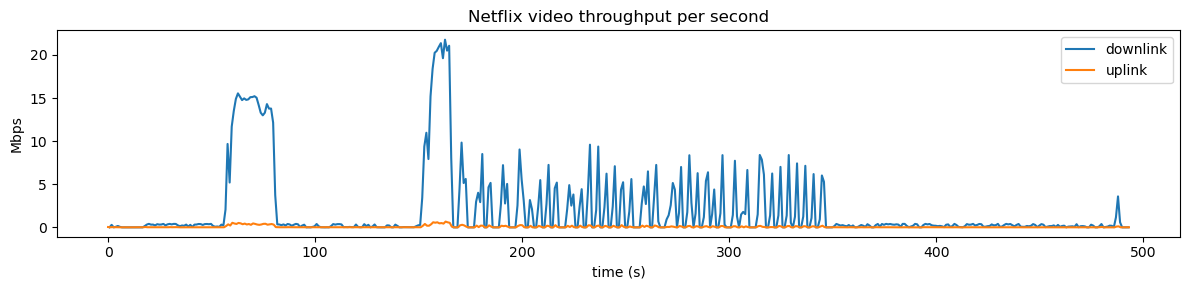

downlink Mbps: median 0.23, p90 7.24, max 21.77  |  seconds carrying nothing: 113 of 493
uplink Mbps:   median 0.0074, max 0.668


In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
for direction, g in pkts.groupby("uplink"):
    s = g.set_index(pd.to_timedelta(g["t"], unit="s"))["length"].resample("1s").sum() * 8 / 1e6
    ax.plot(s.index.total_seconds(), s.values, label="uplink" if direction else "downlink")
ax.set(xlabel="time (s)", ylabel="Mbps", title="Netflix video throughput per second")
ax.legend(); plt.tight_layout(); plt.show()

dl_s = (pkts[~pkts["uplink"]].set_index(pd.to_timedelta(pkts.loc[~pkts["uplink"], "t"], unit="s"))
        ["length"].resample("1s").sum() * 8 / 1e6)
ul_s = (pkts[pkts["uplink"]].set_index(pd.to_timedelta(pkts.loc[pkts["uplink"], "t"], unit="s"))
        ["length"].resample("1s").sum() * 8 / 1e6)
print(f"downlink Mbps: median {dl_s.median():.2f}, p90 {dl_s.quantile(0.9):.2f}, max {dl_s.max():.2f}"
      f"  |  seconds carrying nothing: {(dl_s == 0).sum()} of {len(dl_s)}")
print(f"uplink Mbps:   median {ul_s.median():.4f}, max {ul_s.max():.3f}")


**Reading the throughput plot.** This one figure is basically the argument for the whole project.
Downlink throughput is wildly bursty. The median second carries 0.23 Mbps, the 90th percentile
carries 7.24 Mbps, and the busiest second hits 21.77 Mbps, while 113 of the 493 seconds carry
nothing at all. If you tried to read video quality off this line you would conclude the stream was
constantly changing, and it wasn't. The encoded bitrate underneath sits near 2 Mbps the whole time
(§9.1).

That gap between a signal that swings from 0 to 21.77 Mbps and a bitrate that barely moves is
exactly why throughput can't answer the question and why chunk boundaries can. The uplink line is
almost flat against it, median 0.0074 Mbps and peaking at 0.668, which is what you'd expect when the
client is only sending small requests and acknowledgements. That asymmetry is also what makes the
labeling strategy possible, since the few hundred bytes the client does send are easy to pick out.

## 3. Derive request labels from the uplink

We treat a client-to-server TCP segment on a video connection as a chunk request when all four of
these hold:

1. it isn't a retransmission, meaning this is the first time we've seen this `(connection, seq)` pair
2. it starts with a TLS application-data record (type 23)
3. it carries between `REQ_MIN_PAYLOAD` and `REQ_MAX_PAYLOAD` bytes of TCP payload. On this trace the
   requests land between 667 and 695 bytes, which is about what an encrypted HTTP GET with headers
   should weigh. The rest of the uplink data is ClientHellos at 517 bytes, handshake messages
   between 126 and 227, and ChangeCipherSpec or alert records at 51, all of which sit outside that
   range
4. it arrives at least `REQ_IDLE_S` = 0.25 s after the previous uplink data segment on the same
   connection

**Why 0.25 s**, with the evidence in §3.1. Requests that follow a shorter gap mostly pull small
responses, median around 70 KB, and they look like startup or seek fetches of non-chunk objects
rather than media. Requests with gaps between 0.25 and 2 s pull roughly 1 MB and are real chunks
fetched during buffer-filling bursts, so pushing the threshold higher would start throwing away
genuine chunks. We settled this on label-validity grounds before looking at any model scores, and
§8.1 reports what happens at 0 s and 0.5 s instead.

**The circularity risk.** These labels are a heuristic and not ground truth. The model only ever
sees downlink features, so it can't copy the answer off the uplink. But if the labeling rule is
wrong in some consistent way, the model will happily learn the same mistake and we'd never see it
in the scores.

In [6]:
REQ_MIN_PAYLOAD = 600    # bytes of TCP payload
REQ_MAX_PAYLOAD = 800
REQ_IDLE_S = 0.25        # min gap since the previous uplink data segment on the same connection (see §3.1)
IDLE_GAP_ALTERNATIVES = [0.0, 0.25, 0.5]   # re-evaluated in §8.2

up_data = pkts[pkts["uplink"] & (pkts["payload_len"] > 0)].copy()
up_data["retransmission"] = up_data.duplicated(["conn", "seq"])
up_data = up_data[~up_data["retransmission"]]
up_data["gap"] = up_data.groupby("conn")["t"].diff().fillna(np.inf)

print("Uplink data segments by TLS record type and payload size:")
display(up_data.groupby(["tls_type", "payload_len"]).size().rename("count").to_frame().T)

candidates = up_data[(up_data["tls_type"] == 23)
                     & up_data["payload_len"].between(REQ_MIN_PAYLOAD, REQ_MAX_PAYLOAD)]

sensitivity = pd.DataFrame([
    dict(idle_gap_s=g, requests=int((candidates["gap"] > g).sum()),
         request_windows=candidates.loc[candidates["gap"] > g, "t"].floordiv(WINDOW_S).nunique())
    for g in [0.0, 0.25, 0.5, 1.0, 2.0]
])
display(sensitivity)

requests = candidates.loc[candidates["gap"] > REQ_IDLE_S, ["t", "conn", "payload_len", "gap"]].reset_index(drop=True)
print(f"{len(requests)} labeled requests on {requests.conn.nunique()} connections (REQ_IDLE_S={REQ_IDLE_S})")

Uplink data segments by TLS record type and payload size:


tls_type     20  22              23                             
payload_len 51  126 223 227 517 667 680 682 683 690 692 694  695
count        17  17   4  13  17   1   1   7   2  37  20  12  110

,idle_gap_s,requests,request_windows
0,0.00,190,137
1,0.25,153,120
2,0.50,139,108
3,1.00,126,101
4,2.00,78,64


153 labeled requests on 12 connections (REQ_IDLE_S=0.25)


### 3.1 Choosing the idle gap

For every candidate request that passes rules 1 to 3, before any gap filter is applied, we measure
two things.

The first is **response size**, meaning the downlink payload on that same connection up until the
next candidate appears there. The second is whether the **previous response was still flowing**,
which we check by looking for server data segments over 100 bytes on that connection in the 50 ms
before the request. If the server was still sending, there was no downlink idle period for a model
to detect in the first place.

We then group the candidates by their gap. A good threshold should drop the groups that don't look
like media chunks while keeping the ones that do.

In [7]:
down_all = pkts[~pkts["uplink"]]
down_data = down_all[down_all["payload_len"] > 100]

cand_rows = []
for conn, g in candidates.groupby("conn"):
    d = down_all[down_all["conn"] == conn]
    dd = down_data[down_data["conn"] == conn]
    starts = g["t"].values
    ends = np.r_[starts[1:], np.inf]
    for (_, r), b in zip(g.iterrows(), ends):
        cand_rows.append(dict(
            t=r.t, conn=conn, gap=r.gap,
            response_mb=d.loc[(d["t"] >= r.t) & (d["t"] < b), "payload_len"].sum() / 1e6,
            prev_still_flowing=((dd["t"] > r.t - 0.05) & (dd["t"] < r.t)).any(),
        ))
cand_chunks = pd.DataFrame(cand_rows).sort_values("t")
cand_chunks["gap_bin"] = pd.cut(cand_chunks["gap"], [0, 0.25, 0.5, 1, 2, np.inf])

(cand_chunks.groupby("gap_bin", observed=True)
 .agg(requests=("t", "size"),
      median_response_mb=("response_mb", "median"),
      share_response_ge_150kb=("response_mb", lambda s: (s >= 0.15).mean()),
      prev_response_still_flowing=("prev_still_flowing", "mean"),
      total_mb=("response_mb", "sum"))
 .round(2))

,requests,median_response_mb,share_response_ge_150kb,prev_response_still_flowing,total_mb
gap_bin,,,,,
"(0.0, 0.25]",37,0.07,0.30,0.89,7.43
"(0.25, 0.5]",14,0.83,0.79,0.86,9.42
"(0.5, 1.0]",13,0.26,0.85,0.69,6.05
"(1.0, 2.0]",48,0.97,0.98,0.90,40.02
"(2.0, inf]",78,0.89,0.95,0.17,59.70


### 3.2 Sanity checks on the chosen labels

If these labels are right, two things should show up. Steady-state spacing between requests on a
single connection ought to sit near multiples of 2 s, since Netflix chunks run about 2 to 4 s, with
some short bursts at startup. And the downlink bytes between consecutive requests on a connection
should land near the chunk sizes the proposal quoted, around 0.2 MB and around 1 MB.

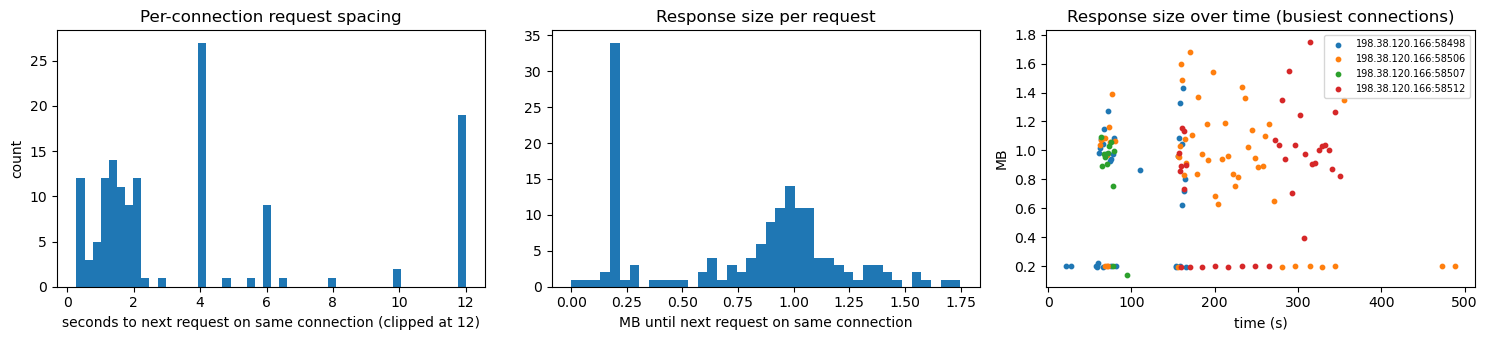

spacing: median 2.00 s, 19% inside 3.5-4.5 s, 14% under 1 s
response: median 0.912 MB, 50% between 0.8 and 1.2 MB
ABR ramp: median response in first 60 s = 0.199 MB, after 60 s = 0.942 MB


In [8]:
# Response bytes per request: downlink payload on the same connection until the next request there
chunk_rows = []
for conn, g in requests.groupby("conn"):
    d = down_all[down_all["conn"] == conn]
    starts = g["t"].values
    ends = np.r_[starts[1:], np.inf]
    for a, b in zip(starts, ends):
        chunk_rows.append(dict(conn=conn, t=a, spacing=b - a,
                               response_mb=d.loc[(d["t"] >= a) & (d["t"] < b), "payload_len"].sum() / 1e6))
label_chunks = pd.DataFrame(chunk_rows).sort_values("t")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(label_chunks["spacing"].replace(np.inf, np.nan).dropna().clip(upper=12), bins=48)
axes[0].set(xlabel="seconds to next request on same connection (clipped at 12)", ylabel="count",
            title="Per-connection request spacing")
axes[1].hist(label_chunks["response_mb"], bins=40)
axes[1].set(xlabel="MB until next request on same connection", title="Response size per request")
for conn, g in label_chunks.groupby("conn"):
    if len(g) >= 10:
        axes[2].scatter(g["t"], g["response_mb"], s=10, label=conn)
axes[2].set(xlabel="time (s)", ylabel="MB", title="Response size over time (busiest connections)")
axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

label_chunks.groupby("conn")[["spacing", "response_mb"]].agg(["count", "median"]).round(3)

_sp = label_chunks["spacing"].replace(np.inf, np.nan).dropna()
print(f"spacing: median {_sp.median():.2f} s, {_sp.between(3.5, 4.5).mean():.0%} inside 3.5-4.5 s, "
      f"{(_sp < 1).mean():.0%} under 1 s")
print(f"response: median {label_chunks['response_mb'].median():.3f} MB, "
      f"{label_chunks['response_mb'].between(0.8, 1.2).mean():.0%} between 0.8 and 1.2 MB")
print(f"ABR ramp: median response in first 60 s = {label_chunks.loc[label_chunks.t < 60, 'response_mb'].median():.3f} MB, "
      f"after 60 s = {label_chunks.loc[label_chunks.t >= 60, 'response_mb'].median():.3f} MB")


**Reading the three panels.** The left panel is the clearest evidence that our labels are picking up
something real. Per-connection request spacing piles up at 2 s and again around 4 s, with 19% of
gaps landing inside the narrow 3.5 to 4.5 s band. Netflix chunks are documented at roughly 4 s, and
we did not put that number anywhere in the labeling rule, so the cadence is coming from the data
rather than from our assumptions. The 14% of gaps under 1 s are the parallel fetches discussed in
§10.5, where two connections request at nearly the same moment.

The middle panel shows response sizes clustering hard around 0.912 MB, with half of all responses
between 0.8 and 1.2 MB. Compare that against the proposal's estimate of about 1 MB per chunk at
1080p and it lines up almost exactly.

The right panel is the one worth pausing on. The small responses aren't scattered randomly through
the session, they're concentrated at the start. Median response size in the first 60 seconds is
0.199 MB, and after that it jumps to 0.942 MB. The proposal predicted about 0.2 MB at 480p and about
1 MB at 1080p, so what we're watching is the adaptive bitrate ladder climbing: the player opens at a
low quality while it works out how much bandwidth it has, then settles at 1080p and stays there.
That single panel is why the session ends up being 83% one tier, which comes back to bite the tier
metric in §10.3.

### 3.3 How many requests can we even score separately?

Two chunk requests can land inside the same 250 ms window, and when that happens the window carries
a single label, so no model can get credit for finding both. It's worth measuring this up front,
because it puts a cap on every score we report later on.

In [9]:
req_w = (requests["t"] // WINDOW_S).astype(int)
dupes = req_w.value_counts()
print(f"uplink requests                 : {len(requests)}")
print(f"distinct 250 ms request windows : {req_w.nunique()}  "
      f"({req_w.nunique() / len(requests):.1%} of requests separately representable)")
print(f"windows holding >1 request      : {(dupes > 1).sum()} (max {dupes.max()} in one window)")
print("\nThe remaining requests are not lost from the evaluation, but they can never be")
print("scored as separate detections. §5.1 turns this into a concrete ceiling on F1.")

uplink requests                 : 153
distinct 250 ms request windows : 120  (78.4% of requests separately representable)
windows holding >1 request      : 29 (max 3 in one window)

The remaining requests are not lost from the evaluation, but they can never be
scored as separate detections. §5.1 turns this into a concrete ceiling on F1.


## 4. Windowing and downlink-only features

Each window is 250 ms long and every feature comes from downlink packets only. The rolling features
look strictly backward, covering the current window plus earlier ones, so nothing from the future
leaks in.

| feature | description |
|---|---|
| `bytes`, `pkts` | downlink byte and packet count |
| `size_mean`, `size_max` | packet size stats |
| `iat_mean`, `iat_var` | inter-arrival time stats within the window |
| `since_empty` | seconds since the last empty downlink window |
| `bytes_1s`, `bytes_4s` | trailing rolling byte totals |
| `active_conns` | distinct server connections with downlink packets in the window |

In [10]:
down = pkts[~pkts["uplink"]].copy()
n_windows = int(np.ceil(pkts["t"].max() / WINDOW_S))
down["w"] = (down["t"] // WINDOW_S).astype(int)
down["iat"] = down["t"].diff()
# Only keep IATs between packets in the same window
down.loc[down["w"] != down["w"].shift(), "iat"] = np.nan

agg = down.groupby("w").agg(
    bytes=("length", "sum"),
    pkts=("length", "size"),
    size_mean=("length", "mean"),
    size_max=("length", "max"),
    iat_mean=("iat", "mean"),
    iat_var=("iat", "var"),
    active_conns=("conn", "nunique"),
)
win = agg.reindex(range(n_windows)).fillna(0.0)
win.index.name = "w"
win["t_start"] = win.index * WINDOW_S

empty = win["pkts"] == 0
last_empty = pd.Series(np.where(empty, win.index, np.nan), index=win.index).ffill().fillna(-1)
win["since_empty"] = (win.index - last_empty) * WINDOW_S

win["bytes_1s"] = win["bytes"].rolling(int(1 / WINDOW_S), min_periods=1).sum()
win["bytes_4s"] = win["bytes"].rolling(int(4 / WINDOW_S), min_periods=1).sum()



def window_labels(request_times):
    # 1 if the window contains at least one uplink-derived request
    y = np.zeros(n_windows, int)
    y[np.clip((np.asarray(request_times) // WINDOW_S).astype(int), 0, n_windows - 1)] = 1
    return y


win["label"] = window_labels(requests["t"])

FEATURES = ["bytes", "pkts", "size_mean", "size_max", "iat_mean", "iat_var",
            "since_empty", "bytes_1s", "bytes_4s", "active_conns"]
print(f"{len(win)} windows, {win.label.sum()} positives ({win.label.mean():.1%})")
win.describe().T

1974 windows, 120 positives (6.1%)


,count,mean,std,min,25%,50%,75%,max
bytes,1974.0,6.501564e+04,1.440275e+05,0.0,0.0000,3028.000000,1.211200e+04,7.009820e+05
pkts,1974.0,4.331814e+01,9.551198e+01,0.0,0.0000,2.000000,9.000000e+00,4.630000e+02
size_mean,1974.0,8.151332e+02,7.385733e+02,0.0,0.0000,1405.784722,1.514000e+03,1.514000e+03
size_max,1974.0,8.373698e+02,7.506236e+02,0.0,0.0000,1514.000000,1.514000e+03,1.514000e+03
iat_mean,1974.0,1.094117e-02,1.879742e-02,0.0,0.0000,0.000580,3.018048e-02,1.493051e-01
iat_var,1974.0,1.587228e-04,9.420375e-04,0.0,0.0000,0.000000,7.213169e-07,1.907749e-02
active_conns,1974.0,9.295846e-01,1.101354e+00,0.0,0.0000,1.000000,1.000000e+00,9.000000e+00
t_start,1974.0,2.466250e+02,1.424973e+02,0.0,123.3125,246.625000,3.699375e+02,4.932500e+02
since_empty,1974.0,1.932751e+00,4.231659e+00,0.0,0.0000,0.250000,1.687500e+00,2.850000e+01
bytes_1s,1974.0,2.600619e+05,5.420909e+05,0.0,66.0000,25738.000000,9.727325e+04,2.743706e+06


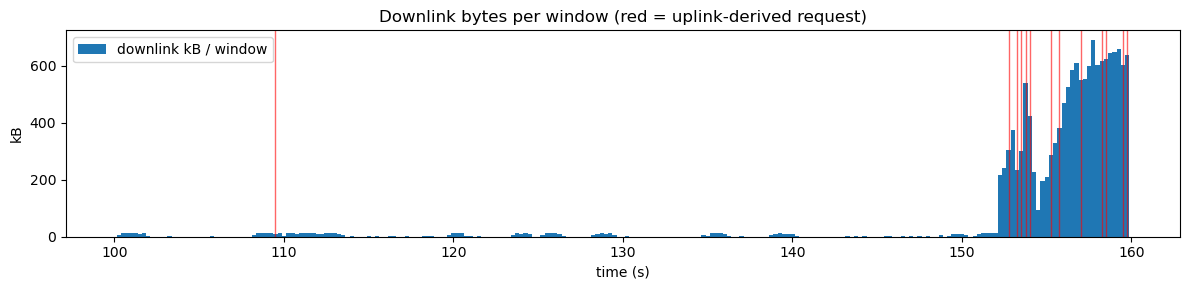

slice 100-160 s: 239 windows, 13 labelled requests, 42% of windows empty, busiest window 689 kB


In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
sl = win.loc[(win.t_start > 100) & (win.t_start < 160)]
ax.bar(sl.t_start, sl["bytes"] / 1e3, width=WINDOW_S, label="downlink kB / window")
for t in sl.loc[sl.label == 1, "t_start"]:
    ax.axvline(t, color="red", alpha=0.6, lw=1)
ax.set(xlabel="time (s)", ylabel="kB", title="Downlink bytes per window (red = uplink-derived request)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"slice 100-160 s: {len(sl)} windows, {int(sl.label.sum())} labelled requests, "
      f"{(sl['bytes'] == 0).mean():.0%} of windows empty, busiest window {sl['bytes'].max()/1e3:.0f} kB")


**Reading the window plot.** This is a 60 second slice of the actual input the models see, with the
uplink-derived labels drawn on top in red. Two things stand out.

The traffic is genuinely on and off rather than continuous. 42% of the windows in this slice are
completely empty, and the busiest one carries 689 kB. So the model isn't looking for a subtle
deviation in a steady stream, it's looking for which of the many burst onsets happens to be a chunk
request.

That's the hard part, and it's visible here. There are 13 labelled requests in this slice but far
more than 13 bursts. Plenty of traffic resumes after a quiet gap without a chunk request behind it,
which is precisely why the idle-gap heuristic racks up false positives and why "resumed after
silence" isn't sufficient on its own.

## 5. Evaluation helpers

**Tolerant matching.** A predicted request counts as a true positive when it falls within
±`TOL_WINDOWS` of a true request that hasn't already been claimed, matched greedily one-to-one.
Whatever predictions are left over become false positives, and whatever true requests are left over
become false negatives.

**Run collapsing.** A run of consecutive positive windows gets reduced to its first window, so a
single burst produces a single request rather than several.

**How we split the data, and why it isn't random.** This is a time series, so a random K-fold split
would be actively misleading here. Windows next to each other in time are heavily correlated, and
`bytes_4s` in particular pools traffic from the previous 16 windows, so a randomly chosen test
window would almost always have several of its own neighbours sitting in the training set. The model
could then score well by recognising traffic it had already partly seen rather than by learning
anything about request timing.

So we cut five contiguous blocks in time order and hold out one block at a time. On top of that, any
window sitting within `PURGE` of the test block is dropped from training, because the 4 s rolling
features would otherwise still leak straight across the boundary even with contiguous blocks.

That gives a nested arrangement overall. The five outer blocks are what every reported score is
measured on, and inside each one's training portion we run a second blocked split to choose the
decision threshold (§7) and the baseline's gap threshold (§6). No test block is ever consulted for
any fitting or tuning decision. There is no separate final hold-out set beyond this, because with
only 120 positives in the whole session, carving one off would leave too few to measure anything
with, so cross-validated scores are what we report.

In [12]:
PURGE = int(4 / WINDOW_S)  # windows


def collapse_runs(pred):
    pred = np.asarray(pred).astype(bool)
    starts = pred & ~np.r_[False, pred[:-1]]
    return starts.astype(int)


def tolerant_match(y_true, y_pred, tol=TOL_WINDOWS):
    true_idx = np.flatnonzero(y_true)
    pred_idx = np.flatnonzero(y_pred)
    used = np.zeros(len(true_idx), bool)
    tp = 0
    for p in pred_idx:
        cand = np.flatnonzero((np.abs(true_idx - p) <= tol) & ~used)
        if len(cand):
            used[cand[np.argmin(np.abs(true_idx[cand] - p))]] = True
            tp += 1
    fp = len(pred_idx) - tp
    fn = len(true_idx) - tp
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return dict(tp=tp, fp=fp, fn=fn, precision=prec, recall=rec, f1=f1)


def tolerant_confusion(y_true, y_pred, tol=TOL_WINDOWS):
    m = tolerant_match(y_true, y_pred, tol)
    tn = len(y_true) - m["tp"] - m["fp"] - m["fn"]
    return np.array([[tn, m["fp"]], [m["fn"], m["tp"]]])


def blocked_folds(n, k=N_FOLDS, purge=PURGE):
    edges = np.linspace(0, n, k + 1).astype(int)
    idx = np.arange(n)
    for i in range(k):
        lo, hi = edges[i], edges[i + 1]
        test = idx[lo:hi]
        train = idx[(idx < lo - purge) | (idx >= hi + purge)]
        yield i, train, test

### 5.1 The oracle ceiling

`collapse_runs` reduces a run of consecutive positive windows down to one prediction, and §3.3
already showed that some windows carry more than one request. Between them, those two facts mean a
perfect predictor still can't score 1.0.

So the cleanest way to find the ceiling is to feed the evaluation a perfect prediction, the labels
themselves, and see what comes back. Anything below that number is the model falling short.
Anything above it was never available in the first place.

In [13]:
oracle = tolerant_match(win["label"].values, collapse_runs(win["label"].values))
print("oracle (perfect window predictions, after run-collapsing):")
print(f"  precision {oracle['precision']:.3f}   recall {oracle['recall']:.3f}   F1 {oracle['f1']:.3f}")
print(f"  {oracle['fn']} of {int(win['label'].sum())} labelled windows are unreachable because an")
print("  adjacent window is also labelled and the two collapse into one prediction.")
ORACLE_F1 = oracle["f1"]

oracle (perfect window predictions, after run-collapsing):
  precision 1.000   recall 0.792   F1 0.884
  25 of 120 labelled windows are unreachable because an
  adjacent window is also labelled and the two collapse into one prediction.


## 6. Baseline: the idle-gap heuristic, no ML involved

We flag a request in any window where downlink traffic picks back up after at least `gap` seconds of
silence. In practice that means a non-empty window whose preceding `gap / WINDOW_S` windows were all
empty. The gap threshold itself is chosen on the training folds only.

In [14]:
GAP_GRID = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]


def idle_gap_predict(bytes_series, gap_s):
    k = max(1, int(round(gap_s / WINDOW_S)))
    active = (np.asarray(bytes_series) > 0).astype(int)
    prev_active = pd.Series(active).shift(1).rolling(k, min_periods=k).sum().fillna(k).values
    return ((active == 1) & (prev_active == 0)).astype(int)


def fit_baseline(bytes_train, y_train):
    scores = {g: tolerant_match(y_train, idle_gap_predict(bytes_train, g))["f1"] for g in GAP_GRID}
    return max(scores, key=scores.get)

## 7. Models

**L1 logistic regression**, scaled, with `class_weight="balanced"`. We expect this to be the weakest
of the three.

**Random forest**, also with `class_weight="balanced"` and otherwise fairly default settings.

**Gradient-boosted trees**, with shallow trees and a small learning rate to keep overfitting under
control.

One thing worth flagging: the probability threshold is not fixed at 0.5. With positives making up
only 6% of windows and `class_weight="balanced"` already in play, 0.5 is an arbitrary operating
point, and eyeballing a better one against the test folds would just be leakage with extra steps.
Instead every outer fold runs an inner blocked split across its own training windows and picks the
threshold there, so the test block never gets consulted. Hyperparameters stay at the defaults above.
The threshold is the only thing we tune.

In [15]:
MODELS = {
    "logreg_l1": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", solver="liblinear", C=1.0, class_weight="balanced", max_iter=5000),
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, class_weight="balanced", n_jobs=-1, random_state=42,
    ),
    "gbt": HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=300, class_weight="balanced", random_state=42,
    ),
}

THRESHOLD_GRID = np.round(np.arange(0.10, 0.91, 0.05), 2)
N_INNER_FOLDS = 4


def tune_threshold(est, X_train, y_train):
    """Pick the probability threshold on an inner blocked split of the TRAINING windows only.

    Scores are pooled over the inner folds (tp/fp/fn summed, then F1) rather than averaged,
    because an inner fold can easily contain too few positives for its own F1 to mean anything.
    """
    counts = {t: dict(tp=0, fp=0, fn=0) for t in THRESHOLD_GRID}
    for _, inner_tr, inner_te in blocked_folds(len(y_train), k=N_INNER_FOLDS):
        m = clone(est).fit(X_train[inner_tr], y_train[inner_tr])
        proba = m.predict_proba(X_train[inner_te])[:, 1]
        for t in THRESHOLD_GRID:
            s = tolerant_match(y_train[inner_te], collapse_runs(proba >= t))
            for k in ("tp", "fp", "fn"):
                counts[t][k] += s[k]
    f1 = {t: (2 * c["tp"] / (2 * c["tp"] + c["fp"] + c["fn"]) if c["tp"] else 0.0)
          for t, c in counts.items()}
    return max(f1, key=f1.get)

## 8. Blocked cross-validation for request detection

We lead with pooled precision, recall and F1, summing TP, FP and FN over the five test folds, and
report the per-fold spread next to them so the stability is visible too. The positives are spread
very unevenly over time, and the final fold is mostly idle, fully buffered playback with only a
handful of request windows in it, so its per-fold F1 can swing between 0 and 1 on a single hit.

In [16]:
X = win[FEATURES].values
byte_counts = win["bytes"].values


def run_blocked_cv(y, tune=True):
    fold_rows = []
    preds = {name: np.zeros(len(y), int) for name in ["baseline", *MODELS]}
    conf = {name: np.zeros((2, 2), int) for name in preds}
    for fold, tr, te in blocked_folds(len(y)):
        # Baseline: gap threshold chosen on the training windows only
        gap = fit_baseline(byte_counts[tr], y[tr])
        p = idle_gap_predict(byte_counts[te], gap)
        preds["baseline"][te] = p
        fold_rows.append(dict(model="baseline", fold=fold, param=f"gap={gap}s", **tolerant_match(y[te], p)))
        conf["baseline"] += tolerant_confusion(y[te], p)

        # ML models: probability threshold chosen on an inner blocked split of the training windows
        for name, est in MODELS.items():
            thr = tune_threshold(est, X[tr], y[tr]) if tune else 0.5
            m = clone(est).fit(X[tr], y[tr])
            p = collapse_runs(m.predict_proba(X[te])[:, 1] >= thr)
            preds[name][te] = p
            fold_rows.append(dict(model=name, fold=fold, param=f"thr={thr}", **tolerant_match(y[te], p)))
            conf[name] += tolerant_confusion(y[te], p)
    return pd.DataFrame(fold_rows), preds, conf


def pooled_scores(folds):
    # Micro-averaged over folds: robust when a fold has only a handful of positives
    t = folds.groupby("model")[["tp", "fp", "fn"]].sum()
    t["precision"] = t["tp"] / (t["tp"] + t["fp"])
    t["recall"] = t["tp"] / (t["tp"] + t["fn"])
    t["f1"] = 2 * t["precision"] * t["recall"] / (t["precision"] + t["recall"])
    return t.fillna(0.0)


y = win["label"].values
folds, fold_preds, conf = run_blocked_cv(y)

for fold, tr, te in blocked_folds(len(y)):
    print(f"fold {fold}: t={win.t_start.iloc[te[0]]:.0f}-{win.t_start.iloc[te[-1]]:.0f} s, {y[te].sum()} positive windows")

print("\nthreshold / gap chosen per fold (training data only):")
display(folds.pivot(index="fold", columns="model", values="param"))

display(pooled_scores(folds).round(3))
summary = (folds.groupby("model")[["precision", "recall", "f1"]]
           .agg(["mean", "std", "min", "max"]).round(3))
summary

fold 0: t=0-98 s, 45 positive windows
fold 1: t=98-197 s, 30 positive windows
fold 2: t=197-296 s, 25 positive windows
fold 3: t=296-394 s, 16 positive windows
fold 4: t=395-493 s, 4 positive windows

threshold / gap chosen per fold (training data only):


model,baseline,gbt,logreg_l1,random_forest
fold,,,,
0,gap=2.0s,thr=0.7,thr=0.6,thr=0.15
1,gap=1.0s,thr=0.45,thr=0.6,thr=0.1
2,gap=2.0s,thr=0.55,thr=0.75,thr=0.55
3,gap=1.0s,thr=0.5,thr=0.75,thr=0.45
4,gap=1.0s,thr=0.5,thr=0.65,thr=0.6


,tp,fp,fn,precision,recall,f1
model,,,,,,
baseline,33,26,87,0.559,0.275,0.369
gbt,62,24,58,0.721,0.517,0.602
logreg_l1,45,88,75,0.338,0.375,0.356
random_forest,45,35,75,0.562,0.375,0.450


precision                     recall                       \
                   mean    std   min    max   mean    std    min    max   
model                                                                     
baseline          0.388  0.406  0.00  0.944  0.307  0.351  0.000  0.688   
gbt               0.698  0.284  0.40  1.000  0.474  0.205  0.250  0.800   
logreg_l1         0.467  0.471  0.03  1.000  0.418  0.329  0.089  0.920   
random_forest     0.459  0.319  0.00  0.714  0.307  0.226  0.000  0.600   

                  f1                       
                mean    std    min    max  
model                                      
baseline       0.334  0.367  0.000  0.791  
gbt            0.536  0.163  0.333  0.678  
logreg_l1      0.411  0.395  0.054  0.939  
random_forest  0.364  0.258  0.000  0.652

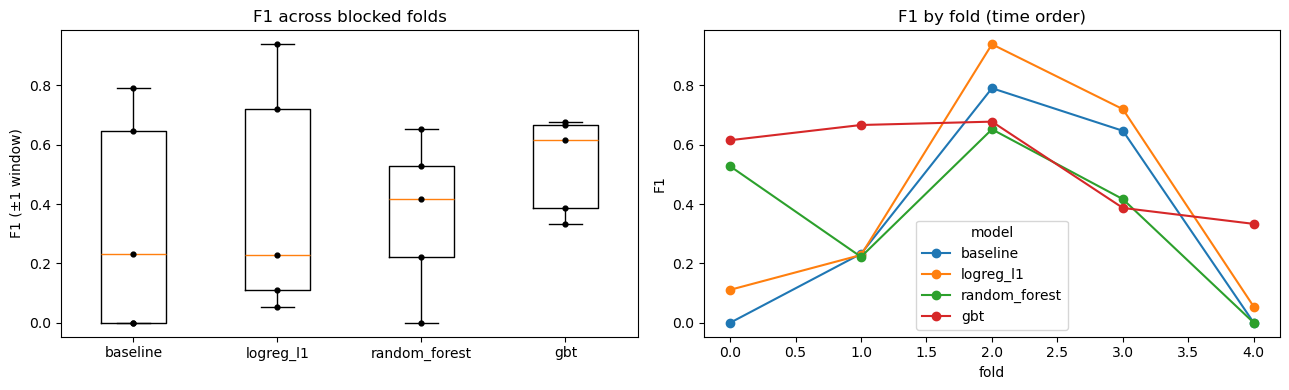

F1 by fold (time order):


model,baseline,logreg_l1,random_forest,gbt
fold,,,,
0,0.000,0.111,0.528,0.615
1,0.233,0.229,0.222,0.667
2,0.791,0.939,0.652,0.678
3,0.647,0.720,0.417,0.387
4,0.000,0.054,0.000,0.333


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ["baseline", *MODELS]
data = [folds.loc[folds.model == m, "f1"] for m in order]
axes[0].boxplot(data, tick_labels=order)
for i, d in enumerate(data, 1):
    axes[0].scatter(np.full(len(d), i), d, color="k", s=12, zorder=3)
axes[0].set(ylabel=f"F1 (±{TOL_WINDOWS} window)", title="F1 across blocked folds")

folds.pivot(index="fold", columns="model", values="f1")[order].plot(marker="o", ax=axes[1])
axes[1].set(ylabel="F1", title="F1 by fold (time order)")
plt.tight_layout(); plt.show()

print("F1 by fold (time order):")
display(folds.pivot(index="fold", columns="model", values="f1")[order].round(3))


**Reading the fold plots.** The left panel shows the spread of F1 across folds and the right shows
the same scores in time order, which is the more informative of the two.

| fold | time | baseline | logreg | random forest | GBT |
|---|---|---|---|---|---|
| 0 | 0 to 98 s | 0.000 | 0.111 | 0.528 | 0.615 |
| 1 | 98 to 197 s | 0.233 | 0.229 | 0.222 | 0.667 |
| 2 | 197 to 296 s | 0.791 | 0.939 | 0.652 | 0.678 |
| 3 | 296 to 394 s | 0.647 | 0.720 | 0.417 | 0.387 |
| 4 | 395 to 493 s | 0.000 | 0.054 | 0.000 | 0.333 |

The right panel makes the pattern obvious once you read it left to right. The baseline scores zero
on fold 0 and zero again on fold 4, and does its best work in the middle of the session. That isn't
random noise, it's the session structure showing through. Fold 0 is startup, where the player is
filling its buffer with back-to-back requests and there are barely any idle gaps to trigger on.
Fold 4 is fully buffered playback, where traffic is so sparse that almost every resumption looks
like a request. The heuristic only works in the steady middle stretch where requests arrive on a
regular cadence with clean silence between them.

Logistic regression follows the baseline's shape almost exactly, peaking at 0.939 on fold 2 and
collapsing at both ends. That similarity is itself a result: the linear model has essentially
rediscovered the heuristic rather than improving on it.

GBT is the only model that stays in a narrow band across all five folds, never above 0.678 and never
below 0.333. It gives up the spectacular fold 2 scores the other two models post, and in exchange it
doesn't fall over at the edges of the session. For an operator who has to run this continuously
rather than on a hand-picked window, that trade is the entire point.

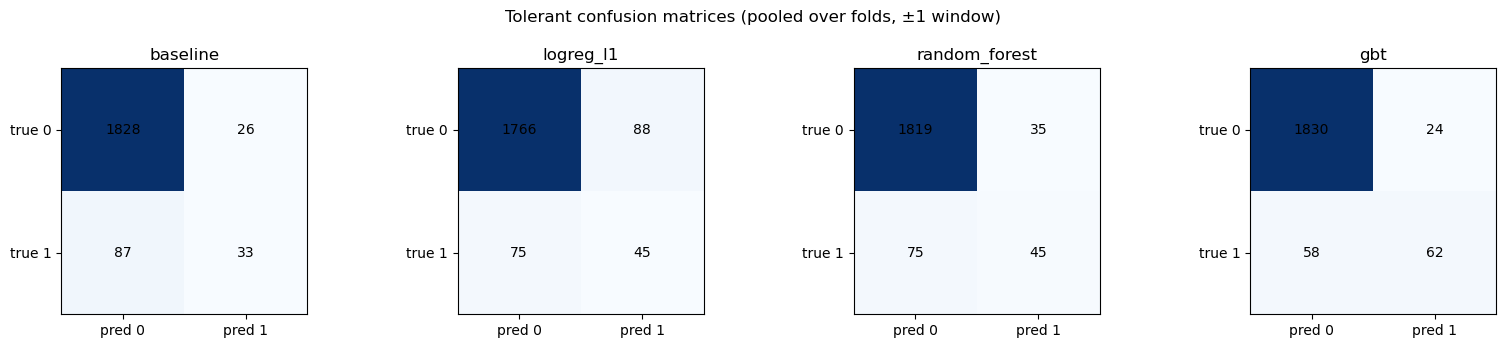

pooled counts:


,TN,FP,FN,TP
baseline,1828,26,87,33
logreg_l1,1766,88,75,45
random_forest,1819,35,75,45
gbt,1830,24,58,62


In [18]:
fig, axes = plt.subplots(1, len(conf), figsize=(4 * len(conf), 3.5))
for ax, (name, cm) in zip(axes, conf.items()):
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v}", ha="center", va="center")
    ax.set(title=name, xticks=[0, 1], yticks=[0, 1],
           xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
plt.suptitle(f"Tolerant confusion matrices (pooled over folds, ±{TOL_WINDOWS} window)")
plt.tight_layout(); plt.show()

print("pooled counts:")
display(pd.DataFrame({k: dict(TN=v[0, 0], FP=v[0, 1], FN=v[1, 0], TP=v[1, 1])
                      for k, v in conf.items()}).T)


**Reading the confusion matrices.** These are pooled over all five folds with the ±1 window
tolerance applied, so the counts describe the whole session.

| model | TN | FP | FN | TP |
|---|---|---|---|---|
| baseline | 1828 | 26 | 87 | 33 |
| logreg | 1766 | 88 | 75 | 45 |
| random forest | 1819 | 35 | 75 | 45 |
| GBT | 1830 | 24 | 58 | 62 |

The first thing to notice is the shape of the problem. There are roughly 1,850 true negatives against
120 positives in every matrix, so anything that predicted "no request" for all 1,974 windows would
score about 94% accuracy while being completely useless. That imbalance is why we never report
accuracy and work from precision, recall and F1 instead.

The second is the direct comparison between logistic regression and the random forest. They have
identical true positives and false negatives, 45 and 75, so they find exactly the same number of
requests. The difference is entirely in the false positive column, where logistic regression racks
up 88 against the forest's 35. Same recall, two and a half times the noise, and that single column is
where its F1 goes.

GBT is the only model that moves the false negative count meaningfully, dropping it from 75 to 58
while also posting the lowest false positive count at 24. Even so, 58 missed requests out of 120 is
a lot. It's finding just over half of them, and §10.4 traces what that does to the bitrate estimate
downstream.

### 8.1 Label sensitivity: does any of this depend on the idle gap?

The main results are built on `REQ_IDLE_S` = 0.25 s. Here we rerun the whole cross-validation with
labels rebuilt at each value in `IDLE_GAP_ALTERNATIVES`, holding features, folds and models fixed.

This is a robustness check and not a way of choosing the threshold. If the models stop beating the
baseline as the rows change, then the headline claim needs softening.

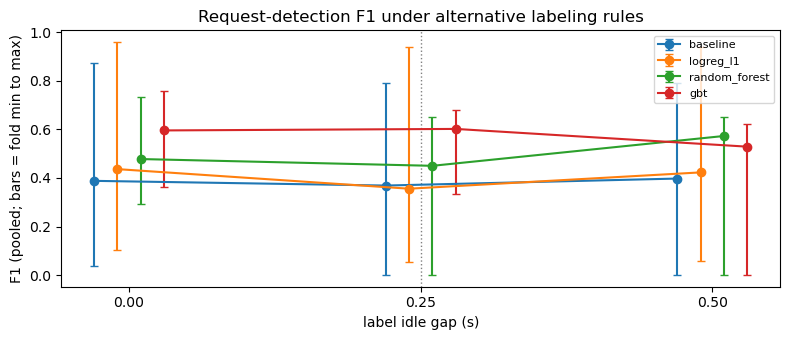

positives               f1_pooled               f1_min         \
idle_gap_s         0.00   0.25   0.50      0.00   0.25   0.50   0.00   0.25   
model                                                                         
baseline          137.0  120.0  108.0     0.388  0.369  0.398  0.036  0.000   
gbt               137.0  120.0  108.0     0.596  0.602  0.529  0.364  0.333   
logreg_l1         137.0  120.0  108.0     0.436  0.356  0.423  0.104  0.054   
random_forest     137.0  120.0  108.0     0.478  0.450  0.573  0.294  0.000   

                     f1_max                
idle_gap_s      0.50   0.00   0.25   0.50  
model                                      
baseline       0.000  0.875  0.791  0.791  
gbt            0.000  0.759  0.678  0.621  
logreg_l1      0.057  0.960  0.939  0.939  
random_forest  0.000  0.732  0.652  0.653

In [19]:
sens_rows = []
for g in IDLE_GAP_ALTERNATIVES:
    y_alt = window_labels(candidates.loc[candidates["gap"] > g, "t"])
    f_alt, _, _ = run_blocked_cv(y_alt)
    pooled = pooled_scores(f_alt)
    for model, fm in f_alt.groupby("model"):
        sens_rows.append(dict(idle_gap_s=g, positives=int(y_alt.sum()), model=model,
                              f1_pooled=pooled.loc[model, "f1"],
                              f1_mean=fm["f1"].mean(), f1_min=fm["f1"].min(), f1_max=fm["f1"].max()))
label_sensitivity = pd.DataFrame(sens_rows)

fig, ax = plt.subplots(figsize=(8, 3.5))
order = ["baseline", *MODELS]
offsets = np.linspace(-0.03, 0.03, len(order))
for off, model in zip(offsets, order):
    s = label_sensitivity[label_sensitivity["model"] == model]
    ax.errorbar(s["idle_gap_s"] + off, s["f1_pooled"],
                yerr=[(s["f1_pooled"] - s["f1_min"]).clip(lower=0), (s["f1_max"] - s["f1_pooled"]).clip(lower=0)],
                marker="o", capsize=3, label=model)
ax.axvline(REQ_IDLE_S, color="grey", ls=":", lw=1)
ax.set(xlabel="label idle gap (s)", ylabel="F1 (pooled; bars = fold min to max)", xticks=IDLE_GAP_ALTERNATIVES,
       title="Request-detection F1 under alternative labeling rules")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

label_sensitivity.pivot(index="model", columns="idle_gap_s", values=["positives", "f1_pooled", "f1_min", "f1_max"]).round(3)

**Reading the sensitivity plot.** Each point is a pooled F1 with the labels rebuilt from scratch at
that idle gap, and the bars show the fold minimum and maximum.

The useful signal here is the vertical ordering, not the exact heights. GBT and the random forest sit
above the baseline at all three settings, so the claim that tree ensembles beat the heuristic doesn't
depend on where we put the threshold. The error bars, though, are enormous for every model, which is
a fair reminder that with only 120 positives split across five folds, single-fold scores carry very
little information on their own.

The place to be careful is the right-hand side. At 0.5 s the random forest reaches 0.573 and GBT
falls to 0.529, so the two swap places. That's why §10.2 draws the conclusion at the level of model
families rather than naming GBT the definitive winner. A result that survives relabeling is worth
reporting. A ranking that flips is not.

### 8.2 Feature importance, measured out of fold

Permutation importance computed on each held-out block and then averaged across folds, so a feature
only earns a score if it helps on data the model never saw during fitting.

In [20]:
from sklearn.inspection import permutation_importance

# Permutation importance measured on each held-out block, using models fitted on that
# block's training windows only. An in-sample importance on a full-data fit would mostly
# report what the model memorised.
imp_rows = []
for fold, tr, te in blocked_folds(len(y)):
    for name, est in MODELS.items():
        m = clone(est).fit(X[tr], y[tr])
        r = permutation_importance(m, X[te], y[te], scoring="average_precision",
                                   n_repeats=10, random_state=42)
        for feat, val in zip(FEATURES, r.importances_mean):
            imp_rows.append(dict(model=name, fold=fold, feature=feat, importance=val))

perm_imp = pd.DataFrame(imp_rows)
imp_table = perm_imp.pivot_table(index="feature", columns="model", values="importance", aggfunc="mean")
imp_table = imp_table.reindex(FEATURES)

# The L1 coefficients are a full-data fit, kept for interpretability only (sign and sparsity),
# not as an out-of-sample importance estimate.
imp_table["l1_coef (in-sample)"] = pd.Series(
    clone(MODELS["logreg_l1"]).fit(X, y)[-1].coef_[0], index=FEATURES)
imp_table.round(3)

model,gbt,logreg_l1,random_forest,l1_coef (in-sample)
feature,,,,
bytes,0.185,0.000,0.108,0.000
pkts,0.062,0.091,0.029,0.679
size_mean,0.255,0.002,0.184,0.000
size_max,0.000,0.125,-0.003,1.117
iat_mean,-0.057,0.151,-0.054,-1.960
iat_var,-0.027,0.012,-0.009,0.244
since_empty,-0.001,-0.013,-0.023,-0.082
bytes_1s,-0.023,0.038,-0.026,-1.378
bytes_4s,-0.023,0.146,-0.016,0.977


**What the importances actually say.** Two things in this table are worth more than the ranking
itself.

The first is that both tree models lean on `size_mean` and `bytes`, and effectively ignore
`since_empty`. GBT scores 0.255 on `size_mean` and 0.185 on `bytes`, while `since_empty` comes in at
-0.001, meaning permuting it changed nothing at all. That is a genuinely surprising result, because
`since_empty` is the feature that encodes the baseline heuristic's entire logic, which is time
elapsed since the traffic went quiet. The trees are beating the idle-gap heuristic while making
essentially no use of the quantity the heuristic is built on. What they use instead is the texture of
the current window: a chunk response opens with full-MTU packets arriving in bulk, so a window with a
high mean packet size and a high byte count looks different from the trickle of acknowledgements and
control traffic that fills the quiet stretches. The model learned to recognise what a response onset
looks like rather than how long the silence before it was.

The second is what L1 did to the linear model. The `l1_coef` column has exactly two zeros, on `bytes`
and `size_mean`, which are precisely the two features the trees rank highest. L1 dropped them because
on a standardised linear scale they overlap heavily with `pkts` and `size_max` and add nothing a
straight line can use. What logistic regression leans on instead is `iat_mean` at -1.960 and
`bytes_1s` at -1.378, both negative, which amounts to saying "predict a request when packets are
arriving close together and the previous second was quiet". That is a reasonable rule and it is
roughly the heuristic again, which fits what we saw in the fold plots where logistic regression
tracked the baseline's shape almost exactly.

So the linear model is reaching for longer-range context through the rolling features because it has
no way to express a local conjunction, while the trees read the answer off the shape of the current
window. That difference is the clearest explanation we have for the F1 gap between them.

One note on reading the numbers: several importances are slightly negative, which just means
permuting that feature happened to improve the score on held-out data. Those should be read as zero
rather than as evidence the feature hurts.

### 8.3 What the threshold tuning actually cost

Back in §7 we decided not to leave the decision threshold at 0.5, and to have each fold pick its own
value on an inner split of its training windows instead. That's the defensible way to do it, but it
does raise an obvious question: how much of each model's score was resting on the default in the
first place?

`run_blocked_cv` takes a `tune` flag, so we can rerun the whole thing with the threshold pinned back
at 0.5 and put the two side by side. A model that barely moves was never depending on the threshold.
A model that drops a long way was getting help from a value nobody had justified.

In [21]:
folds_untuned, _, _ = run_blocked_cv(y, tune=False)
comparison = pd.DataFrame({
    "F1 @ fixed 0.5": pooled_scores(folds_untuned)["f1"],
    "F1 @ inner-tuned": pooled_scores(folds)["f1"],
})
comparison["change"] = comparison["F1 @ inner-tuned"] - comparison["F1 @ fixed 0.5"]
comparison.round(3)

,F1 @ fixed 0.5,F1 @ inner-tuned,change
model,,,
baseline,0.369,0.369,0.000
gbt,0.612,0.602,-0.010
logreg_l1,0.353,0.356,0.003
random_forest,0.593,0.450,-0.143


## 9. Bitrate recovery

For each detected request, the chunk bytes are the downlink bytes from that request's window up to
the next request's window, and the encoded bitrate is `chunk bytes x 8 / CHUNK_DURATION_S`.

The reasoning here is per-chunk rather than per-second. One detected request kicks off one chunk
download, so those bytes represent `CHUNK_DURATION_S` seconds of playback no matter how long the
wall-clock gap to the next request turns out to be. If we divided by the wall-clock gap instead we'd
just be recovering throughput, which is exactly the quantity the proposal set out to get away from.

The catch is that missing a request merges two chunks into a single interval and roughly doubles the
estimate. Bitrate error ends up being mostly a function of detection recall, so we report the signed
`bias_kbps` next to MAE to keep that visible rather than hidden inside an absolute error.

The tier edges get calibrated in §9.1, against the two connections whose request cadence is clean
enough to read the true encoded bitrate straight off.

In [22]:
# Resolution tiers are defined on encoded bitrate, not raw chunk bytes.
# Anchors come from the proposal's MB-per-4s-chunk figures, converted to kbps:
#   ~0.2 MB -> ~400 kbps (480p), ~1 MB -> ~2000 kbps (1080p), ~8 MB -> ~16000 kbps (4K).
# 720p is interpolated at ~900 kbps. Each boundary sits at the geometric mean of its
# two neighbouring anchors, so a tier spans a constant ratio either side of its anchor.
TIER_ANCHORS_KBPS = [400, 900, 2000, 16000]
TIER_NAMES = ["<=480p", "720p", "1080p", "4K"]
TIER_EDGES_KBPS = ([0]
                   + [float(np.sqrt(a * b)) for a, b in zip(TIER_ANCHORS_KBPS, TIER_ANCHORS_KBPS[1:])]
                   + [np.inf])
print("tier boundaries (kbps):", [round(e) for e in TIER_EDGES_KBPS[1:-1]])


def chunk_series(req_windows, bytes_per_window):
    req_windows = np.flatnonzero(req_windows)
    if len(req_windows) < 2:
        return pd.DataFrame(columns=["w_start", "w_end", "bytes", "kbps"])
    cum = np.r_[0, np.cumsum(bytes_per_window)]
    starts, ends = req_windows[:-1], req_windows[1:]
    b = cum[ends] - cum[starts]
    df = pd.DataFrame(dict(w_start=starts, w_end=ends, bytes=b))
    # One detected request begins one chunk, so the bytes until the next request are
    # one chunk's worth and the playback duration they cover is CHUNK_DURATION_S.
    df["kbps"] = df["bytes"] * 8 / CHUNK_DURATION_S / 1e3
    return df


def to_grid(chunks, n_windows, step_s=1.0):
    # Step function: each second takes the bitrate of the chunk covering it
    grid_w = (np.arange(0, n_windows * WINDOW_S, step_s) / WINDOW_S).astype(int)
    out = pd.Series(np.nan, index=grid_w)
    for r in chunks.itertuples():
        out[(grid_w >= r.w_start) & (grid_w < r.w_end)] = r.kbps
    return out


def tier_of(kbps_series):
    return pd.cut(kbps_series, TIER_EDGES_KBPS, labels=TIER_NAMES)


bpw = win["bytes"].values
ref_grid = to_grid(chunk_series(win["label"].values, bpw), len(win))
ref_tier = tier_of(ref_grid)

bitrate_rows, grids = [], {"uplink labels": ref_grid}
for name, pred in fold_preds.items():
    g = to_grid(chunk_series(pred, bpw), len(win))
    grids[name] = g
    both = g.notna() & ref_grid.notna()
    err = g[both] - ref_grid[both]
    bitrate_rows.append(dict(
        model=name,
        mae_kbps=err.abs().mean(),
        median_ae_kbps=err.abs().median(),
        bias_kbps=err.mean(),                       # signed: exposes systematic over-estimation
        tier_agreement=(tier_of(g)[both] == ref_tier[both]).mean(),
        coverage=both.mean(),
    ))

# Reference point: how well does "always predict the majority tier" do?
majority_tier = ref_tier.value_counts().idxmax()
majority_share = (ref_tier == majority_tier).mean()
bitrate = pd.DataFrame(bitrate_rows).round(
    dict(mae_kbps=0, median_ae_kbps=0, bias_kbps=0, tier_agreement=3, coverage=3))
print(f"\nreference median {ref_grid.median():.0f} kbps; "
      f"majority tier = {majority_tier} on {majority_share:.1%} of covered seconds "
      f"-> a constant '{majority_tier}' predictor already scores {majority_share:.3f}")
bitrate


tier boundaries (kbps): [600, 1342, 5657]

reference median 2226 kbps; majority tier = 1080p on 78.7% of covered seconds -> a constant '1080p' predictor already scores 0.787


,model,mae_kbps,median_ae_kbps,bias_kbps,tier_agreement,coverage
0,baseline,17764.0,1426.0,16451.0,0.479,0.947
1,logreg_l1,7568.0,1916.0,5284.0,0.385,0.947
2,random_forest,3888.0,1509.0,2808.0,0.461,0.672
3,gbt,1419.0,981.0,975.0,0.677,0.870


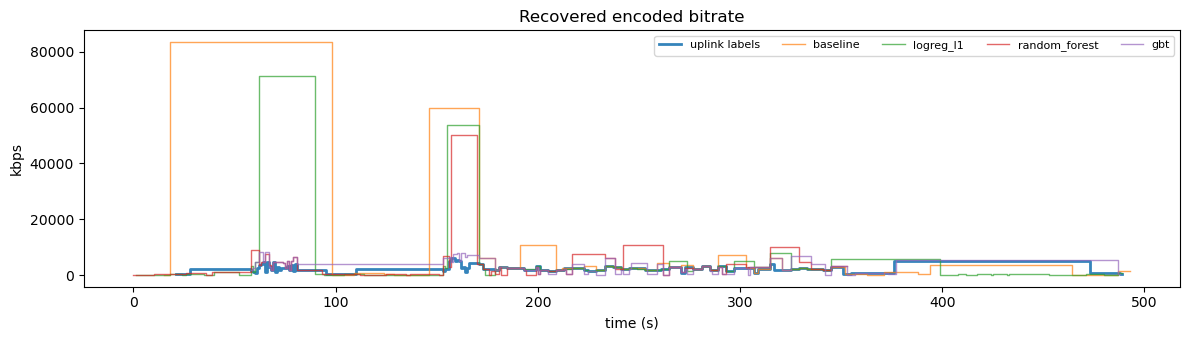

recovered bitrate series:


,median_kbps,p10,p90,seconds_covered
uplink labels,2226.0,912.0,5090.0,468.0
baseline,3337.0,172.0,83513.0,479.0
logreg_l1,1818.0,30.0,7881.0,488.0
random_forest,1971.0,194.0,9981.0,353.0
gbt,3866.0,443.0,6017.0,430.0


In [23]:
fig, ax = plt.subplots(figsize=(12, 3.5))
for name, g in grids.items():
    ax.step(g.index * WINDOW_S, g.values, where="post", label=name,
            lw=2 if name == "uplink labels" else 1, alpha=0.9 if name == "uplink labels" else 0.7)
ax.set(xlabel="time (s)", ylabel="kbps", title="Recovered encoded bitrate")
ax.legend(ncol=5, fontsize=8); plt.tight_layout(); plt.show()

print("recovered bitrate series:")
display(pd.DataFrame({name: dict(median_kbps=g.median(), p10=g.quantile(0.1),
                                 p90=g.quantile(0.9), seconds_covered=int(g.notna().sum()))
                      for name, g in grids.items()}).T.round(0))


**Reading the bitrate plot.** The thick line is the reference built from the uplink labels and the
thin lines are what each model recovers.

| series | median kbps | p10 | p90 | seconds covered |
|---|---|---|---|---|
| uplink labels | 2226 | 912 | 5090 | 468 |
| baseline | 3337 | 172 | 83513 | 479 |
| logreg | 1818 | 30 | 7881 | 488 |
| random forest | 1971 | 194 | 9981 | 353 |
| GBT | 3866 | 443 | 6017 | 430 |

The baseline's p90 of 83,513 kbps is the number to look at, because 83 Mbps is not a plausible
bitrate for anything. Those spikes are the mechanism from §10.4 made visible: miss enough requests in
a row and a long interval accumulates several chunks worth of bytes, which then all get divided by a
single 4 second chunk duration. The reference series never exceeds about 5,090 kbps at p90, so every
one of those tall excursions is an artefact of missed detections rather than anything the stream
actually did.

The random forest's column tells the other half of the story. It only covers 353 seconds against the
reference's 468, so roughly a quarter of the session simply has no line drawn for it. Bitrate is only
defined between two consecutive detections, and a model that misses requests goes quiet rather than
going wrong, which is arguably the more dangerous failure because nothing in the output flags it.

GBT tracks the reference most closely in shape, but its median of 3,866 kbps still sits well above
the reference's 2,226. Even the best model here runs hot, which is the negative result §10.4 is built
on.

### 9.1 Is the reference series itself believable?

The bitrate series built from the uplink labels is the yardstick we measure everything else against,
so it needs a check of its own that doesn't depend on the labels being right.

Two of the connections fetch chunks on a clean, almost exactly 4 s cadence. On those, "one request
means one 4 s chunk" isn't an assumption we're making, it's visible directly in the data, which
means their steady-state chunk size hands us the encoded video bitrate. If the aggregate reference
series agrees with that figure, then the aggregate accounting is sound.

In [24]:
# Ground truth from connections whose request cadence is already ~4 s
truth = []
for conn, g in label_chunks.groupby("conn"):
    steady = g[g["spacing"].between(0.9 * CHUNK_DURATION_S, 1.1 * CHUNK_DURATION_S)]
    if len(steady) >= 10:
        truth.append(dict(conn=conn, steady_chunks=len(steady),
                          median_mb=steady["response_mb"].median(),
                          kbps=steady["response_mb"].median() * 8 / CHUNK_DURATION_S * 1e3))
truth = pd.DataFrame(truth)
display(truth.round(2))

mean_throughput_kbps = down_all["length"].sum() * 8 / pkts["t"].max() / 1e3
print(f"per-connection encoded bitrate : {truth['kbps'].min():.0f}-{truth['kbps'].max():.0f} kbps")
print(f"aggregate reference (median)   : {ref_grid.median():.0f} kbps")
print(f"mean downlink throughput       : {mean_throughput_kbps:.0f} kbps")
print(f"\nreference vs per-connection truth: "
      f"{ref_grid.median() / truth['kbps'].mean() - 1:+.1%}")

# Tier occupancy tells us how much signal the tier metric can carry at all
print("\nreference tier occupancy (% of covered seconds):")
display((ref_tier.value_counts(normalize=True).reindex(TIER_NAMES).fillna(0) * 100).round(1))

,conn,steady_chunks,median_mb,kbps
0,198.38.120.166:58506,13,1.02,2049.55
1,198.38.120.166:58512,14,1.02,2032.91


per-connection encoded bitrate : 2033-2050 kbps
aggregate reference (median)   : 2226 kbps
mean downlink throughput       : 2081 kbps

reference vs per-connection truth: +9.0%

reference tier occupancy (% of covered seconds):


<=480p     5.8
720p      10.7
1080p     83.1
4K         0.4
Name: proportion, dtype: float64

## 10. Results and discussion

Everything below comes from the run in this notebook. Scores are pooled (micro-averaged) across the
five blocked folds, and each model picked its own decision threshold using only an inner split of
its training windows.

### 10.1 Does ML beat the baseline?

Partly. One model beats it clearly and the other two really don't.

| model | precision | recall | F1 (pooled) | F1 per fold: mean / min / max |
|---|---|---|---|---|
| idle-gap baseline | 0.559 | 0.275 | **0.369** | 0.334 / 0.000 / 0.791 |
| L1 logistic regression | 0.338 | 0.375 | **0.356** | 0.411 / 0.054 / 0.939 |
| random forest | 0.562 | 0.375 | **0.450** | 0.364 / 0.000 / 0.652 |
| gradient-boosted trees | 0.721 | 0.517 | **0.602** | 0.536 / 0.333 / 0.678 |

GBT is the only clear win. It comes out ahead on pooled F1, on mean fold F1, and on its worst fold,
which is probably the most telling of the three. Its minimum of 0.333 is roughly what the baseline
manages on average (0.334), while the baseline's own minimum is a flat zero. That gap says something
about the heuristic beyond it just being weaker. It's unstable. A single idle-gap threshold has to
cover both the heavy buffer-filling burst at the start of the session and the thin, fully-buffered
traffic at the end, and no single value does both, so it swings from 0.791 on one fold to 0.000 on
another. GBT's spread across folds (std 0.163) is less than half of that (0.367).

Logistic regression is the disappointment. Its pooled F1 of 0.356 actually lands below the
baseline, and the reason is visible in the counts: 88 false positives against only 45 true ones. Its
fold mean of 0.411 looks better than the baseline's 0.334, but that comes from one fold scoring
0.939 and another scoring 0.054, which is exactly the kind of swing that makes pooling the more
honest headline. The proposal guessed this model would be weakest and that turned out right. Finding
a chunk request really means spotting a combination of things happening at once, a big burst of
bytes that arrives right after a quiet stretch, and a linear model working from these features has
no way to express that kind of interaction.

Random forest sits in the middle, and it's shakier than it first looked. With the threshold pinned
at 0.5 it scored 0.593, but once each fold had to choose its own threshold on training data only, it
dropped to 0.450 (§8.3). The thresholds its inner folds picked ranged from 0.10 all the way to 0.60,
which suggests the operating point was never stable to begin with. GBT barely moved under the same
change, going from 0.612 to 0.602, and that contrast is the interesting part. The random forest
needed a lucky threshold and GBT didn't.

There's also the question of what 0.602 is worth. Two requests can land in the same 250 ms window,
and `collapse_runs` folds adjacent positive windows into one prediction, so even a perfect predictor
loses some credit. Feeding the labels back in as if they were predictions gives F1 0.884 with
precision 1.000 and recall 0.792 (§5.1). Measured against that ceiling rather than against a
hypothetical 1.0, GBT is getting about 68% of what's actually available, and roughly a third of the
apparent shortfall belongs to the evaluation setup rather than the model.

### 10.2 Circularity

Our labels are a heuristic, which means the models are being graded against a rule we invented
rather than against truth. If that rule is wrong in some consistent way, every number above is wrong
with it. Three things limit how bad that could be, though none of them make the problem go away.

The first is that the labels and the features come from opposite directions. Labels are derived from
the uplink and every feature is downlink-only, so the model can't just read the answer off the same
packets that defined it.

The second is the sensitivity check in §8.1. Rebuilding the labels at idle gaps of 0, 0.25 and 0.5
seconds gives this:

| model | 0.00 s | 0.25 s | 0.50 s |
|---|---|---|---|
| baseline | 0.388 | 0.369 | 0.398 |
| logreg | 0.436 | 0.356 | 0.423 |
| random forest | 0.478 | 0.450 | **0.573** |
| GBT | 0.596 | **0.602** | 0.529 |

GBT stays ahead of the baseline at all three settings, so the main claim holds up. But the order
among the ML models does shuffle. At 0.5 seconds the random forest (0.573) passes GBT (0.529). We
shouldn't be saying GBT is reliably the best model. What we can say is that tree ensembles reliably
beat the heuristic, and that GBT wins under the labeling rule we argued for in §3.1.

The third check is physical, and it's the one that reassures us most. The labels imply a request
cadence of almost exactly 4.00 seconds on the two busiest connections, with a steady-state chunk of
1.02 MB, which works out to somewhere between 2033 and 2050 kbps. Mean measured downlink throughput
across the whole session is 2081 kbps. A rule that was just picking up noise would not land within
2% of Netflix's documented 4-second chunk structure by accident.

What none of that covers: the rule was tuned on this one trace, the 600 to 800 byte payload window
is specific to this client and TLS version, and a bias shared by the labels and the features alike
would slip past all three checks without a trace.

### 10.3 What TLS actually leaks

The timing of chunk requests comes through, and from that we get the chunk cadence of about 4
seconds, the per-chunk byte volume, and a session-level encoded bitrate accurate to roughly 9%
(§9.1). Someone watching nothing but downlink packet sizes and timestamps can work out that a
session is pulling around 1 MB every 4 seconds, which is a 1080p-class stream. That's the operational
case the proposal was making, and it survives.

Resolution tier as a signal that changes over time does not come through, and we'd rather be blunt
about that than dress it up. GBT matches the reference tier on 67.7% of seconds, which sounds
reasonable until you notice the session sits in one tier (1080p) for 78.7% of its covered duration.
A predictor that ignores the data entirely and always answers "1080p" scores 0.787 and beats every
model we trained. Tier agreement just isn't a meaningful measure on a single-tier session. We're
reporting it because the proposal committed us to it, but the right conclusion is that this trace
can't answer the tier question, not that the models were bad at it. Anything convincing on tier
inference needs a capture where the quality actually moves around.

### 10.4 Bitrate recovery, and why it's a negative result

| model | MAE (kbps) | median abs err | **bias (kbps)** | tier agreement | coverage |
|---|---|---|---|---|---|
| baseline | 17764 | 1426 | **+16451** | 0.479 | 0.947 |
| logreg | 7568 | 1916 | **+5284** | 0.385 | 0.947 |
| random forest | 3888 | 1509 | **+2808** | 0.461 | 0.672 |
| GBT | 1419 | 981 | **+975** | 0.677 | 0.870 |
| *constant "1080p"* | | | | *0.787* | |

The bias column is where the story is, and every value in it is positive. The cause is mechanical
rather than statistical. Miss a request and two chunks collapse into one interval, so twice the
bytes end up divided by a single chunk duration. Bitrate error doesn't decay gently as recall drops,
it inflates, and it tracks recall almost exactly. The baseline recovers 27.5% of requests and
overshoots by 16451 kbps. GBT recovers 51.7% and overshoots by 975.

GBT is comfortably the best of a bad set. MAE of 1419 kbps and bias of 975 kbps against a reference
median of 2226 kbps still means it's running about 44% hot. Its median absolute error of 981 kbps
sits well below its mean of 1419, so the errors are skewed, with most chunks estimated tolerably and
a smaller group badly off. Even reading it generously, there's no version of these numbers where the
per-chunk series is something you'd want to use.

The coverage column is worth a look too. The random forest leaves 33% of the session with no
estimate at all, because bitrate is only defined between two consecutive detections. A model that
misses requests doesn't just estimate them badly, it stops producing output.

So the proposal's second question, whether the bitrate estimate holds up, gets a no with conditions
attached. The session average is recoverable to within about 9% straight from the labels (§9.1), but
no model's per-chunk series is trustworthy and the best one is still 44% high. That's a real finding
rather than a failed experiment, and it's the part that would most change how anyone actually
deployed this. Report a rolling average and never a per-chunk number.

### 10.5 Limitations

The biggest one is that this is a single session. 493 seconds, one client, one network, one device,
captured in Paris back in 2018. Nothing here shows the models would survive contact with a different
setup, and the external validation that was meant to test that could not be run at all (§11).

The dataset is also small and heavily autocorrelated, at 1,974 windows with 120 positives. The last
fold contains only 4 positive windows, so a single hit swings its F1 between 0 and 1. That's why we
lead with pooled scores and report the fold spread next to them instead of averaging it away.

The labels are heuristic, with the caveats already covered in §10.2, and the model ranking isn't
stable across labeling rules.

We also aggregate across connections, which costs us more than we expected. Up to four connections
fetch in parallel, and 42 of the 119 inter-request intervals are shorter than half a second, which is
parallel fetching rather than any real chunk boundary. Doing the accounting per connection would be
more faithful, but the model predicts on aggregate downlink windows and has no connection
attribution available at prediction time, so that option isn't open to us. This is a limit on the
method itself rather than on our implementation of it, and it's the main reason the aggregate
reference reads about 9% high against the per-connection ground truth.

Two smaller things: the tier metric is degenerate on this trace (§10.3), and the capture is truncated
at 200 bytes, so the labeling rule leans on TCP payload length instead of properly parsed TLS record
contents.

### 10.6 What we learned

Most of what we took away is about method rather than modelling. The result depended far more on how
we derived labels, how we cut the folds, and which metrics we chose to believe than on whether we
reached for a random forest or gradient boosting.

Building the non-ML baseline first turned out to matter more than we expected, and building it
carefully mattered even more. The idle-gap heuristic hit 0.791 on one fold. If we'd reported only its
mean we'd have hidden how erratic it is, and if we'd reported only its worst fold we'd have
overstated how much ML actually buys us.

We also learned that a metric can be computed perfectly correctly and still be useless. Tier
agreement was in the proposal, we implemented it faithfully, and a constant beats it. The only reason
we caught that was asking what the majority class scores, which took one line of code and should
honestly have been the first thing we checked.

Tuning on the test fold turned out to be very easy to do without noticing. The random forest fell
from 0.593 to 0.450 the moment we replaced the fixed 0.5 threshold with proper inner-fold selection,
while GBT only slipped from 0.612 to 0.602 (§8.3). The first random forest number wasn't dishonest,
but we hadn't earned it either, and the gap between those two reactions tells us more about which
model to trust than the headline scores do.

Time-series splits are genuinely not optional here. With 4-second rolling features on a 250 ms grid,
a random K-fold would have leaked future traffic backwards into training and handed us a much nicer
number that meant nothing. The purge around fold boundaries is there for the same reason.

And finally, a score doesn't mean much until you know the ceiling. 0.602 reads very differently
against an attainable 0.884 than against a nominal 1.0.

### 10.7 Next steps

The obvious first move is validating on a multi-session dataset with real resolution labels. It's the
only way to test whether any of this transfers, and the only way the tier question becomes answerable.

After that, predicting per connection instead of on aggregate windows would deal with both the
parallel-fetch problem and the 9% bias in the aggregate reference.

Swapping the fixed 250 ms grid for an event-based formulation would keep two requests 100 ms apart
distinguishable from each other, which raises the 0.884 oracle ceiling.

Finally, bitrate should be reported as a rolling average with a confidence band around it, following
§10.4, with coverage treated as a real output rather than a footnote.

## 11. Stretch goal: Bronzino et al. (SIGMETRICS 2020), not completed

The proposal listed the labeled dataset from Bronzino et al., *Inferring Streaming Video Quality from
Encrypted Traffic*, as a stretch validation. We did not run it, because the dataset can no longer be
retrieved. The download link on the authors' project page
(`nm-public-data.s3.us-east-2.amazonaws.com/dataset/all_traffic_time_10.pkl`) returns HTTP 403
`AccessDenied`, so the S3 bucket isn't public any more. We checked this rather than assuming it.

Two things seemed worth writing down instead of quietly dropping the goal.

Even if it had downloaded, that release is a pickle of features aggregated over 10-second windows,
built for resolution inference. Our task is locating chunk requests on a 250 ms grid with a tolerance
of plus or minus one window, so a quarter of a second. Features at that coarseness don't transfer,
and validating our main contribution would have meant re-deriving everything from raw packet traces,
which the release doesn't include. The stretch goal was a weaker test of this notebook's central
claim than the proposal assumed it would be.

The consequence holds either way. Every number here comes from one session, and the generalisation
the stretch goal existed to test is still untested. We've put that first in the limitations in §10.5
rather than leaving it buried down here.

If we were to pick this up again, the options are asking the authors directly for the raw traces, or
capturing several sessions ourselves with player-reported ground truth, since Netflix exposes chunk
and bitrate state through its hidden diagnostics panel. That second route is what §10.7 is pointing
at.
